## Used Car Price Prediction
1) Problem statement.

This dataset comprises used cars sold on cardehko.com in India as well as important features of these cars.

If user can predict the price of the car based on input features.

Prediction results can be used to give new seller the price suggestion based on market condition.

2) Data Collection.
The Dataset is collected from scrapping from cardheko webiste

The data consists of 14 column and 15411 rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv("cardekho_imputated.csv")
df.head() 

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## Data Cleaning

Handling Missing values

Handling Duplicates

Check data type

Understand the dataset

In [3]:
## Check NULL Values 
## Check features with the Nan values 
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [4]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [5]:
## Check all the categories 
df['model'].value_counts()

model
i20             906
Swift Dzire     890
Swift           781
Alto            778
City            757
               ... 
Altroz            1
C                 1
Ghost             1
Quattroporte      1
Gurkha            1
Name: count, Length: 120, dtype: int64

In [6]:
df['seller_type'].value_counts()

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

In [7]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

In [8]:
df['transmission_type'].value_counts()

transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

In [9]:
## Remove uneccessary features
df.drop('car_name',axis=1,inplace=True )
df.drop('brand',axis=1,inplace=True )
df.drop('Unnamed: 0',axis=1,inplace=True )

In [10]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [11]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [12]:
model_counts = df['model'].value_counts()
valid_models = model_counts[model_counts > 10].index
df = df[df['model'].isin(valid_models)]
print(df['model'].value_counts())

model
i20            906
Swift Dzire    890
Swift          781
Alto           778
City           757
              ... 
Cayenne         16
XUV300          15
S-Presso        13
Triber          12
GLS             12
Name: count, Length: 82, dtype: int64


In [13]:
models = df['model'].unique()
print(models)

['Alto' 'Grand' 'i20' 'Ecosport' 'Wagon R' 'i10' 'Venue' 'Swift' 'Verna'
 'Duster' 'Cooper' 'Ciaz' 'C-Class' 'Innova' 'Baleno' 'Swift Dzire'
 'Vento' 'Creta' 'City' 'Bolero' 'Fortuner' 'KWID' 'Amaze' 'Santro'
 'XUV500' 'KUV100' 'Ignis' 'RediGO' 'Scorpio' 'Marazzo' 'Aspire' 'Figo'
 'Vitara' 'Tiago' 'Polo' 'Seltos' 'Celerio' 'GO' '5' 'CR-V' 'Endeavour'
 'KUV' 'Jazz' '3' 'A4' 'Tigor' 'Ertiga' 'Safari' 'Thar' 'Hexa' 'Rover'
 'Eeco' 'A6' 'E-Class' 'Q7' '6' 'XF' 'X5' 'Hector' 'Civic' 'Cayenne' 'X1'
 'Rapid' 'Freestyle' 'Superb' 'Nexon' 'XUV300' 'Dzire VXI' 'WR-V' 'Triber'
 'Camry' 'Elantra' 'Yaris' 'GL-Class' '7' 'S-Presso' 'S-Class' 'Harrier'
 'X3' 'Octavia' 'Compass' 'GLS']


In [14]:
df['seats'].value_counts()

seats
5    12807
7     1902
8      311
6      120
4       61
9       54
0        1
2        1
Name: count, dtype: int64

In [15]:
df = df[df['seats'] > 0]

## Handle Outliers

In [16]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return data[(data[column] >= lower) & (data[column] <= upper)]

# apply on columns
df = remove_outliers_iqr(df, 'km_driven')
df = remove_outliers_iqr(df, 'engine')
df = remove_outliers_iqr(df, 'max_power')

In [17]:
print(df.describe())

        vehicle_age      km_driven       mileage        engine     max_power  \
count  12121.000000   12121.000000  12121.000000  12121.000000  12121.000000   
mean       5.852405   49156.314083     20.941006   1266.846465     85.790326   
std        2.970440   27369.205595      3.492015    228.306821     20.055881   
min        0.000000     100.000000     10.800000    793.000000     38.400000   
25%        4.000000   28000.000000     18.600000   1197.000000     73.900000   
50%        5.000000   48000.000000     20.510000   1199.000000     82.000000   
75%        8.000000   68000.000000     23.100000   1493.000000     98.600000   
max       29.000000  130000.000000     33.540000   2092.000000    141.100000   

              seats  selling_price  
count  12121.000000   1.212100e+04  
mean       5.100487   5.437384e+05  
std        0.441981   2.646174e+05  
min        4.000000   4.000000e+04  
25%        5.000000   3.500000e+05  
50%        5.000000   5.000000e+05  
75%        5.000000 

km_driven
50000    458
40000    403
70000    382
60000    353
30000    302
        ... 
77253      1
39993      1
31543      1
31180      1
56161      1
Name: count, Length: 3063, dtype: int64


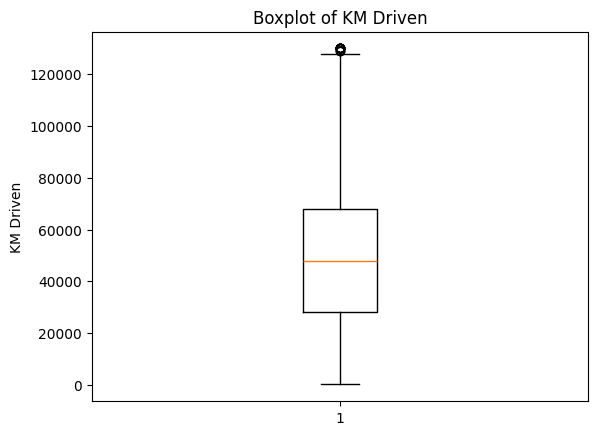

In [18]:
print(df['km_driven'].value_counts())
plt.boxplot(df['km_driven'])
plt.title("Boxplot of KM Driven")
plt.ylabel("KM Driven")
plt.show()

engine
1197    2411
1248    1616
998     1167
1498    1058
1497     656
796      497
1199     466
1396     456
1198     433
1582     412
1086     284
1591     255
1598     249
1373     227
1196     226
999      223
799      202
1461     193
1399     145
1493      99
1462      93
1120      89
1997      83
1061      73
1968      73
1298      63
1799      58
1499      54
1186      48
1047      46
1496      40
1194      22
1956      17
1599      17
1451      12
1998      12
793        9
1353       8
1368       8
1896       6
1984       4
1590       3
2092       3
1343       3
1395       1
1597       1
Name: count, dtype: int64


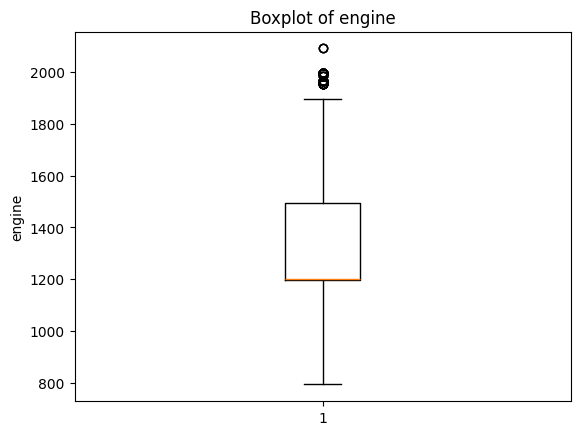

In [19]:
print(df['engine'].value_counts())
plt.boxplot(df['engine'])
plt.title("Boxplot of engine")
plt.ylabel("engine")
plt.show()

max_power
74.00     764
88.50     574
81.80     537
98.60     410
67.04     389
         ... 
65.39       1
130.10      1
119.30      1
62.00       1
75.10       1
Name: count, Length: 167, dtype: int64


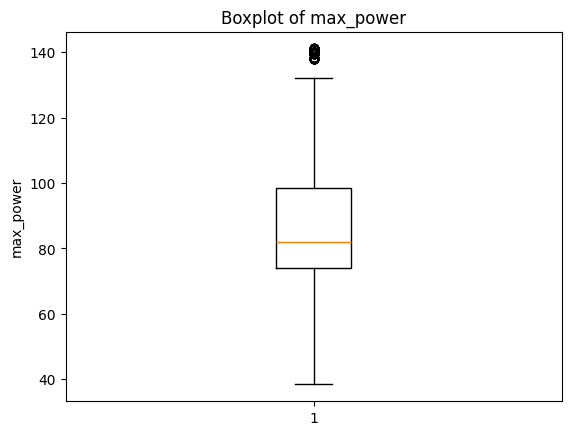

In [20]:
print(df['max_power'].value_counts())
plt.boxplot(df['max_power'])
plt.title("Boxplot of max_power")
plt.ylabel("max_power")
plt.show()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12121 entries, 0 to 15410
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              12121 non-null  object 
 1   vehicle_age        12121 non-null  int64  
 2   km_driven          12121 non-null  int64  
 3   seller_type        12121 non-null  object 
 4   fuel_type          12121 non-null  object 
 5   transmission_type  12121 non-null  object 
 6   mileage            12121 non-null  float64
 7   engine             12121 non-null  int64  
 8   max_power          12121 non-null  float64
 9   seats              12121 non-null  int64  
 10  selling_price      12121 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 1.1+ MB


In [22]:
df.to_csv('cardekho_cleaned.csv', columns=[ 'model','vehicle_age','km_driven','seller_type','fuel_type','transmission_type','mileage','engine','max_power','seats','selling_price'],index=False)

In [23]:
df = pd.read_csv('cardekho_cleaned.csv')
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [24]:
## Getting All Different Types of Features
num_features  = [feature for feature in df.columns if df[feature].dtype != 'O' ]
print('Num of numerical features: ',len(num_features))

cat_features  = [feature for feature in df.columns if df[feature].dtype == 'O' ]
print('Num of categorical features: ',len(cat_features))

discrete_features  = [feature for feature in num_features if len(df[feature].unique()) <=25 ]
print('Num of discrete features: ',len(discrete_features))

continuous_features  = [feature for feature in num_features if feature not in discrete_features ]
print('Num of continuous features: ',len(continuous_features))

Num of numerical features:  7
Num of categorical features:  4
Num of discrete features:  2
Num of continuous features:  5


In [25]:
## Independent and Dependent features 
from sklearn.model_selection import train_test_split

X = df.drop('selling_price',axis=1)
y = df['selling_price']

In [26]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


## Feature Encoding and Scaling
One Hot Encoding for Columns which had lesser unique values and not ordinal

One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

In [27]:
df['model'].unique()

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Ciaz', 'Baleno', 'Swift Dzire',
       'Vento', 'Creta', 'City', 'KWID', 'Amaze', 'Santro', 'Bolero',
       'KUV100', 'Ignis', 'RediGO', 'Scorpio', 'Marazzo', 'Aspire',
       'Figo', 'Vitara', 'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO',
       'KUV', 'Jazz', 'Tigor', 'Ertiga', 'Eeco', 'Civic', 'XUV500',
       'Hector', 'Rapid', 'Freestyle', 'Nexon', 'XUV300', 'Superb',
       'Dzire VXI', 'WR-V', 'Triber', 'Elantra', 'Yaris', 'S-Presso',
       'A4', 'Safari', 'Harrier', 'Octavia', 'Cooper', 'CR-V', 'Innova'],
      dtype=object)

In [28]:
df['model'].value_counts()

model
i20            895
Swift Dzire    863
Alto           773
Swift          766
City           740
Wagon R        708
Grand          574
Verna          483
i10            407
Polo           364
Ecosport       363
Baleno         363
Amaze          356
Ciaz           342
Ertiga         334
Creta          332
KWID           306
Vitara         293
Figo           259
Vento          238
Celerio        237
Duster         202
Rapid          174
Jazz           174
Tiago          145
Santro         136
Eeco           123
WR-V           101
Nexon           85
GO              84
RediGO          75
Ignis           73
KUV             66
Aspire          65
Venue           58
Civic           58
Scorpio         50
Bolero          43
Tigor           37
Octavia         36
Freestyle       33
Seltos          28
XUV500          28
KUV100          27
Elantra         26
A4              25
Marazzo         24
Superb          23
Harrier         17
Yaris           17
Dzire VXI       17
XUV300          15
S-Pres

In [29]:
len(df['seller_type'].unique()),len(df['fuel_type'].unique()),len(df['transmission_type'].unique())

(3, 4, 2)

In [30]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
onehot_columns = ['seller_type','fuel_type','transmission_type']
ordinal_columns = ['model']

from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer  = StandardScaler()
oh_transformer  = OneHotEncoder(drop='first')
ordinal_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer(
    [
        ("StandardScaler",numeric_transformer,num_features),
        ("OneHotEncoder",oh_transformer,onehot_columns),
        ('ordinal', ordinal_transformer, ordinal_columns)
    
    ],remainder='passthrough'

)

In [31]:
X = preprocessor.fit_transform(X)

In [32]:
## Convert array into DataFrame
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.059683,2.588552,-0.355399,-2.062426,-1.969096,-0.227365,1.0,0.0,0.0,0.0,1.0,1.0,1.0
1,-0.286974,-1.065340,-0.584502,-0.305945,-0.188996,-0.227365,1.0,0.0,0.0,0.0,1.0,1.0,22.0
2,1.733012,0.396217,-1.128623,-0.305945,-0.288722,-0.227365,1.0,0.0,0.0,0.0,1.0,1.0,58.0
3,1.059683,-0.444179,-0.006016,-1.177615,-0.931951,-0.227365,1.0,0.0,0.0,0.0,1.0,1.0,1.0
4,0.049690,-0.699951,0.523786,1.012511,0.638227,-0.227365,0.0,0.0,1.0,0.0,0.0,1.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12116,-0.286974,-1.458901,-0.584502,-0.305945,-0.188996,-0.227365,0.0,0.0,0.0,0.0,1.0,1.0,22.0
12117,1.059683,-1.404312,-0.323897,-0.792153,-0.884581,-0.227365,0.0,0.0,0.0,0.0,1.0,1.0,57.0
12118,-1.296968,-1.138418,-0.985433,0.464979,0.264755,4.297904,0.0,0.0,0.0,0.0,1.0,1.0,18.0
12119,0.049690,0.651989,0.056988,1.012511,0.884050,-0.227365,0.0,0.0,1.0,0.0,0.0,1.0,35.0


In [33]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
X_train

array([[ 0.38635442, -0.17981951,  1.21968846, ...,  0.        ,
         1.        , 43.        ],
       [-0.6236388 , -0.88264566,  0.61829161, ...,  1.        ,
         0.        ,  7.        ],
       [ 2.74300525,  1.08855607, -0.89951949, ...,  1.        ,
         1.        ,  9.        ],
       ...,
       [ 1.73301204,  1.12699502, -0.89951949, ...,  0.        ,
         1.        , 43.        ],
       [ 1.39634763,  0.10390522, -0.69905387, ...,  1.        ,
         1.        , 58.        ],
       [ 0.38635442, -0.40307232,  0.50373983, ...,  0.        ,
         1.        , 15.        ]], shape=(9696, 13))

In [35]:
X_test[0]

array([ 1.73301204,  0.94430041, -0.32389679, -0.79215296, -0.88458132,
       -0.22736481,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  1.        , 57.        ])

## Model Training and Model Selection

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [37]:
##Create a Function to Evaluate Model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    r2_Square = r2_score(true,predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    return mae,mse,r2_Square,rmse,

LinearRegression
Model performance for Training set
- Root Mean Squared Error: 139320.0927
- Mean Absolute Error: 100562.1962
- R2 Score: 0.7214
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 140174.3404
- Mean Absolute Error: 101997.4346
- R2 Score: 0.7243




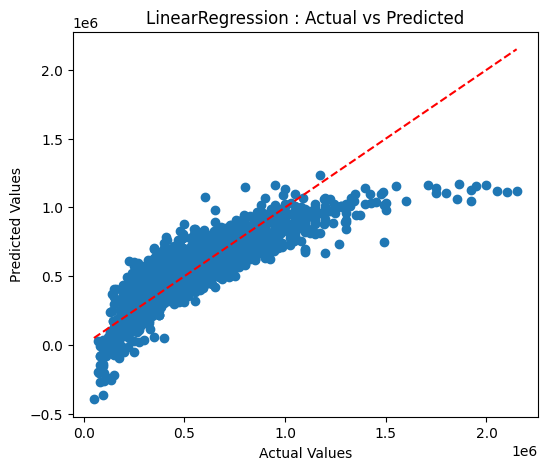

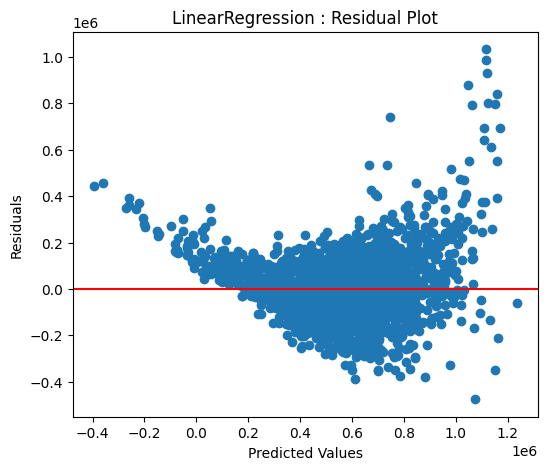

KNN
Model performance for Training set
- Root Mean Squared Error: 76196.2285
- Mean Absolute Error: 51377.3515
- R2 Score: 0.9167
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 86747.2191
- Mean Absolute Error: 63322.8557
- R2 Score: 0.8944




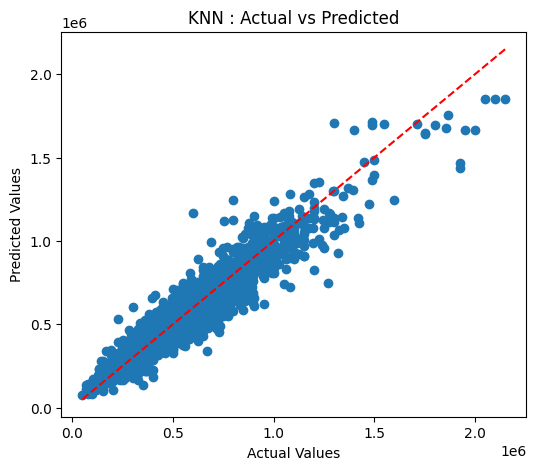

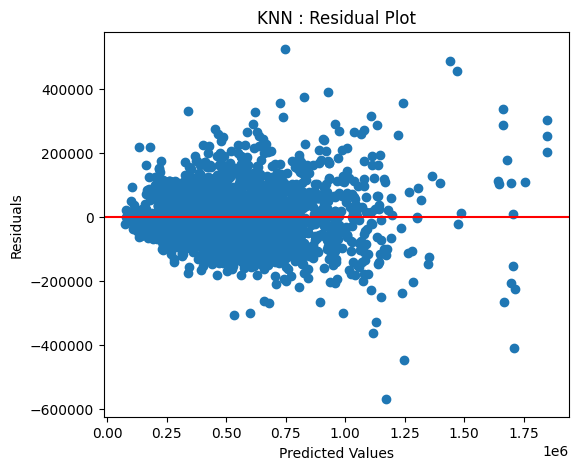

Decision Tree Regressor
Model performance for Training set
- Root Mean Squared Error: 18268.2065
- Mean Absolute Error: 5241.7801
- R2 Score: 0.9952
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 105744.4638
- Mean Absolute Error: 74861.8866
- R2 Score: 0.8431




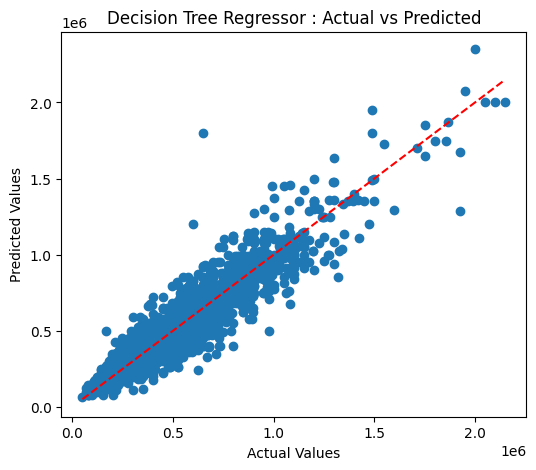

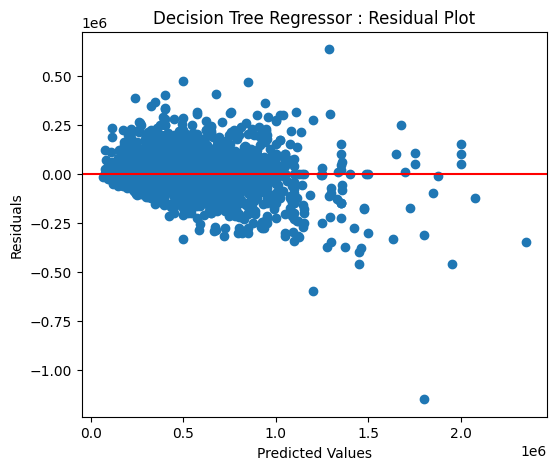

Random Forest
Model performance for Training set
- Root Mean Squared Error: 36694.6131
- Mean Absolute Error: 24940.1423
- R2 Score: 0.9807
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 82942.0313
- Mean Absolute Error: 60346.2010
- R2 Score: 0.9035




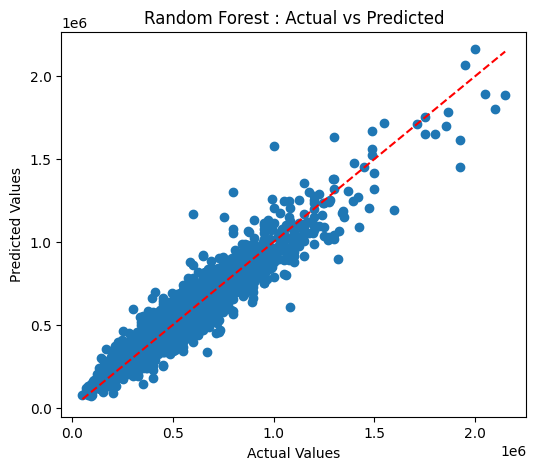

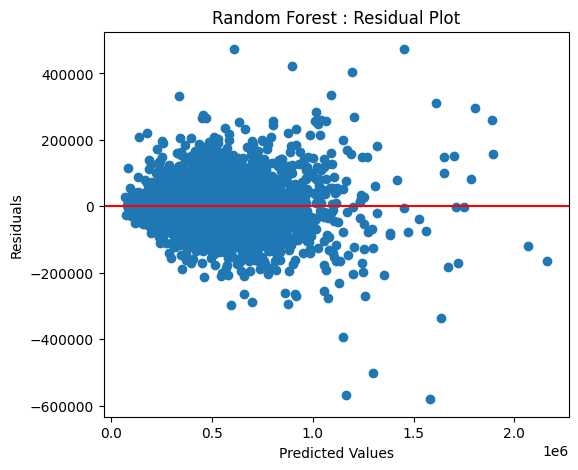

GradientBoosting Regressor 
Model performance for Training set
- Root Mean Squared Error: 84228.9126
- Mean Absolute Error: 61938.0938
- R2 Score: 0.8982
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 87624.0989
- Mean Absolute Error: 64433.0842
- R2 Score: 0.8923




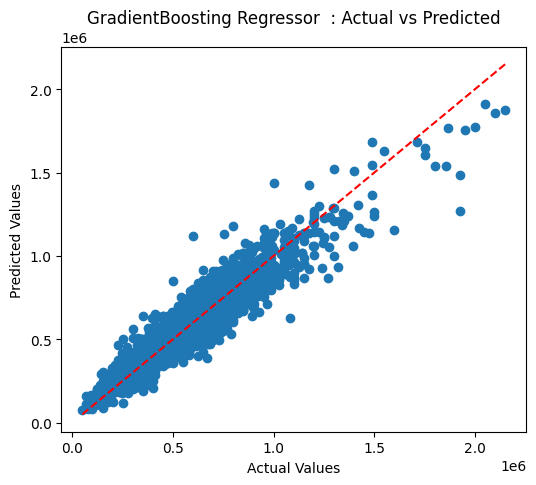

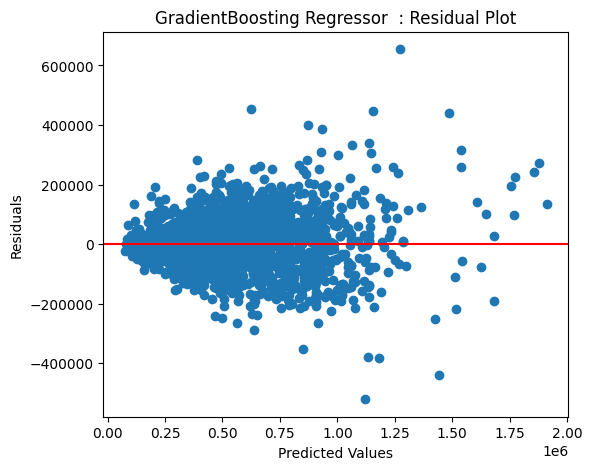

XGBoost Regressor
Model performance for Training set
- Root Mean Squared Error: 56332.2282
- Mean Absolute Error: 42689.1602
- R2 Score: 0.9545
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 80680.2820
- Mean Absolute Error: 59190.6445
- R2 Score: 0.9087




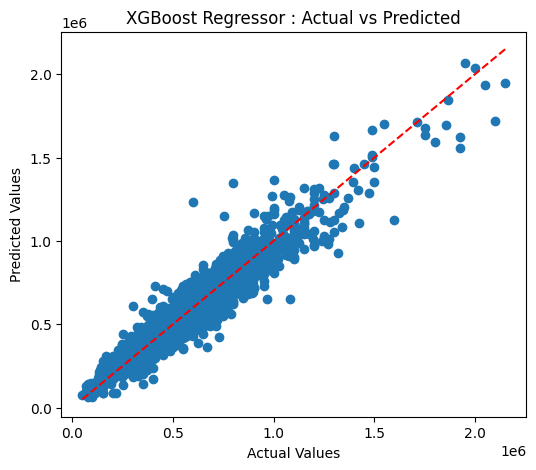

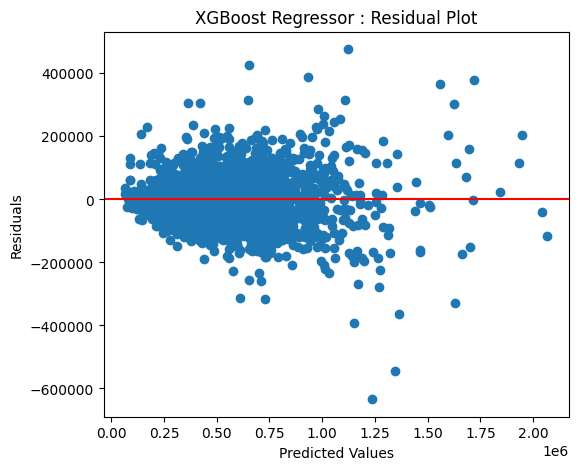

In [38]:
## Beginning Model Training
models = {
    "LinearRegression":LinearRegression(),
    "KNN":KNeighborsRegressor(),
    "Decision Tree Regressor":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(),
    "GradientBoosting Regressor ":GradientBoostingRegressor(),
    "XGBoost Regressor":XGBRegressor()
}

# Store results
model_names = []
r2_scores = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train) ## Train Model

    ## Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    # Evaluate Train and Test dataset
    model_train_mae , model_train_mse, model_train_r2, model_train_rmse= evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2, model_test_rmse = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

    # Save R2 score for comparison
    model_names.append(list(models.keys())[i])
    r2_scores.append(model_test_r2)

    # Graph  : Actual vs Predicted
    # -----------------------------
    plt.figure(figsize=(6,5))

    plt.scatter(y_test, y_test_pred)

    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{list(models.keys())[i]} : Actual vs Predicted")

    plt.show()

    # -----------------------------
    # Graph : Residual Plot
    # -----------------------------
    residuals = y_test - y_test_pred

    plt.figure(figsize=(6,5))

    plt.scatter(y_test_pred, residuals)

    plt.axhline(0, color='red')

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{list(models.keys())[i]} : Residual Plot")

    plt.show()



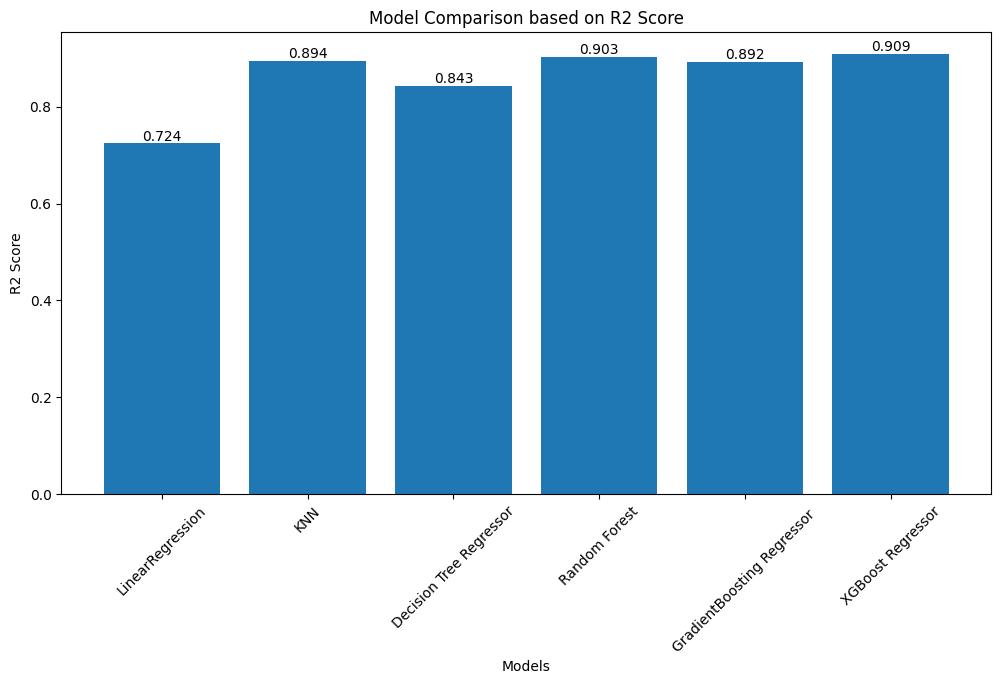

In [39]:
# -----------------------------
# R2 Score Comparison Graph
# -----------------------------
plt.figure(figsize=(12,6))

bars = plt.bar(model_names, r2_scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison based on R2 Score")

plt.xticks(rotation=45)

# Show R2 value on each bar
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{score:.3f}',
             ha='center',
             va='bottom')

plt.show()

## Hyperparameter Tuning

In [ ]:
#Initialize few parameter for Hyperparamter tuning
## knn_params = {"n_neighbors": [2, 3, 10, 20, 40, 50]}
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500]}

gradient_params = {"loss":['squared_error','huber','absolute_error'],
                   "criterion":['friedman_mse','squared_error','mse'],
                   "min_samples_split":[2,7,10,5],
                   "n_estimators":[100,200,300,500],
                   "max_depth":[5,7,3,None,2,10],
                   "learning_rate":[0.1,0.2,0.01]}

xgb_params = {
    "n_estimators":[100,500,300,1000],
    "learning_rate":[0.01,0.3,0.1],
    "max_depth":[3,5,7,10],
    "min_child_weight":[1,3,5]
}

In [48]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ## ("KNN",KNeighborsRegressor(),knn_params),
    ## ("RF",RandomForestRegressor(),rf_params),
    ## ("GB",GradientBoostingRegressor(),gradient_params),
    ("XGB",XGBRegressor(),xgb_params)
]

In [49]:
##Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=50,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 50 candidates, totalling 150 fits
---------------- Best Params for XGB -------------------
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [50]:
## Retraining the models with best parameters
models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=1000, min_samples_split=2, max_features=7, max_depth=15, 
                                                     n_jobs=-1),
    "K-Neighbors Regressor": KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    "GradientBoosting Regressor":GradientBoostingRegressor(n_estimators=200,min_samples_split=5,max_depth=3,loss="squared_error",learning_rate=0.2,criterion="friedman_mse"),
    "XGBoost":XGBRegressor(n_estimator=100,max_depth=7,learning_rate=0.1,min_child_weight=1)
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae ,model_train_mse, model_train_r2, model_train_rmse = evaluate_model(y_train, y_train_pred)

    model_test_mae ,model_test_mse, model_test_r2, model_test_rmse = evaluate_model(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 46380.6879
- Mean Absolute Error: 33780.5793
- R2 Score: 0.9691
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 80658.6062
- Mean Absolute Error: 58657.6926
- R2 Score: 0.9087


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 85949.2952
- Mean Absolute Error: 57062.1700
- R2 Score: 0.8940
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 88440.2674
- Mean Absolute Error: 64556.1340
- R2 Score: 0.8902


GradientBoosting Regressor
Model performance for Training set
- Root Mean Squared Error: 72491.7296
- Mean Absolute Error: 54657.8734
- R2 Score: 0.9246
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 81332.4506
- Mean Absolute Error: 60014.2819
- R2 Score: 0.9072


XGBoost
Model performance for Training set
- Root Mean Squared Error: 61

## Combine with model using Pipeline

In [61]:
## Combine with model using Pipeline
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimator=100,max_depth=7,learning_rate=0.1,min_child_weight=1))
])

In [62]:
## Independent and Dependent features 
from sklearn.model_selection import train_test_split
df = pd.read_csv('cardekho_cleaned.csv')
X = df.drop('selling_price',axis=1)
y = df['selling_price']
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((9696, 10), (2425, 10))

In [63]:
## Train Model
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('StandardScaler', ...), ('OneHotEncoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

                                    feature  importance
4                 StandardScaler__max_power    0.498367
0               StandardScaler__vehicle_age    0.231955
3                    StandardScaler__engine    0.073438
11  OneHotEncoder__transmission_type_Manual    0.058407
12                           ordinal__model    0.043054
8           OneHotEncoder__fuel_type_Diesel    0.032081
5                     StandardScaler__seats    0.021561
10          OneHotEncoder__fuel_type_Petrol    0.015106
2                   StandardScaler__mileage    0.010111
6     OneHotEncoder__seller_type_Individual    0.006810


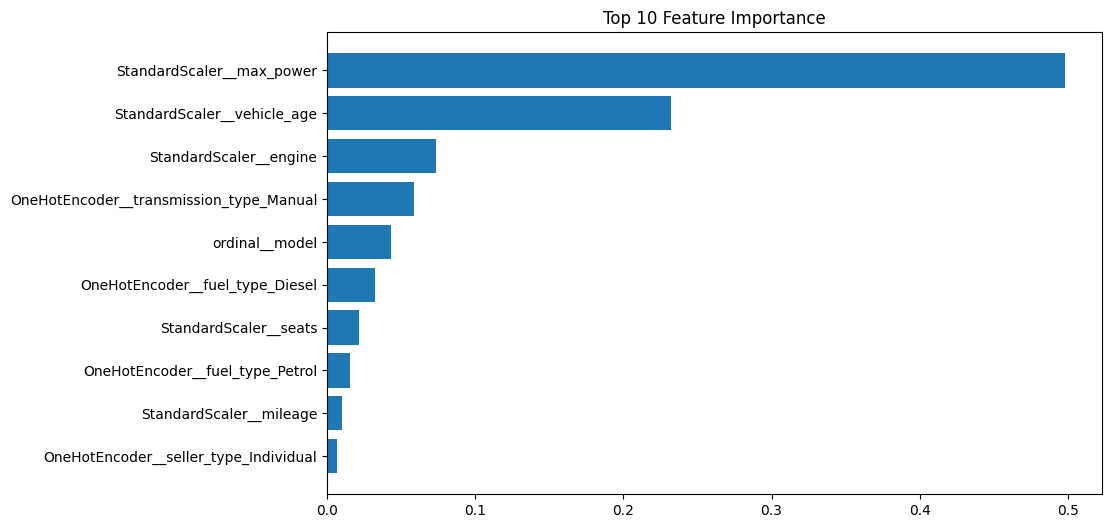

In [64]:
# ================= FEATURE IMPORTANCE =================
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
importance = xgb_model.feature_importances_

import pandas as pd

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['feature'][:10],
         feature_importance_df['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

In [65]:
## save our entire pipeline (preprocessing + model) into a .pkl file.
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(pipe, f)


In [66]:
## load .pkl file for prediction
with open('model.pkl','rb') as g:
    model = pickle.load(g)

In [68]:
## New data for prediction
new_data = pd.DataFrame([{
    'model': 'Swift',
    'vehicle_age': 7,
    'km_driven': 50000,
    'seller_type': 'Dealer',
    'fuel_type': 'Petrol',
    'transmission_type': 'Manual',
    'mileage': 18.97,
    'engine': 1250,
    'max_power': 107.67,
    'seats': 5
}])

prediction = model.predict(new_data)
print(f"Predicted Car {new_data['model'][0]} Price : {int(prediction[0])}")

Predicted Car Swift Price : 503728


In [69]:
## Prediction for new data 
y_pred = pipe.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
4960,270000,237778.328125
2088,700000,628423.687500
396,455000,376346.875000
6385,410000,791278.500000
2619,585000,490774.281250


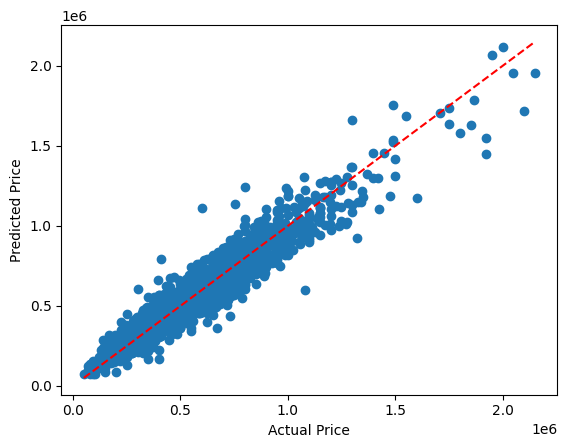

In [71]:
## Comparision between Actual and Predicted Value
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [72]:
## Find r2 Score 
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9124064445495605


In [73]:
## Adjusted R2 Score
n = X_test.shape[0]   # number of rows
k = X_test.shape[1]   # number of features
def adjusted_r2(y_test, y_pred, n, k):
    r2 = r2_score(y_test, y_pred)
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(adjusted_r2(y_test, y_pred, n, k))

0.9120435880646789


In [74]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
print(scores.mean())

0.8942901134490967
